# Example 12: Lunar Navigation Constellation Design

This tutorial designs a lunar navigation constellation for south-pole service. Unlike the previous examples, which estimate the state of one vehicle, this notebook studies the geometry of many relay satellites and many users over time.

We build a reusable `LunarNavConstellation` class that can generate a symmetric ELFO Walker-type constellation, propagate it, compute visibility and dilution of precision, estimate required EIRP, and optimize satellite phasing.

The central design metric is PDOP. If the line-of-sight unit vectors to visible satellites form the geometry matrix $G$, then the covariance-like DOP matrix is

$$
Q=(G^T G)^{-1}, \qquad PDOP=\sqrt{Q_{xx}+Q_{yy}+Q_{zz}}.
$$

Low PDOP means the visible satellites surround the user with strong geometry; high PDOP means the same range noise produces a larger position error. The tutorial optimizes phasing to maximize the fraction of south-pole user-time samples with `PDOP < 6`.

## 0. Imports and constants

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import plotly.graph_objects as go
from scipy.optimize import brentq, differential_evolution

import pylupnt as pnt

np.set_printoptions(precision=4, suppress=True)

# --- Physical constants (SI: metres, seconds, radians) -----------------------
GM_MOON = pnt.GM_MOON  # [m^3/s^2] Moon gravitational parameter
R_MOON = pnt.R_MOON  # [m]       Moon mean radius
OMEGA_EM = (
    pnt.OMEGA_EARTH_MOON
)  # [rad/s]  Earth-Moon mean motion (= Moon spin, tidally locked)
T_SIDEREAL_MONTH = 2 * np.pi / OMEGA_EM  # [s]
J2_MOON = 2.0330e-4  # [-] Moon oblateness (unnormalized C20 magnitude)

RAD, DEG = pnt.RAD, pnt.DEG  # deg->rad and rad->deg multipliers
SECS_HOUR, SECS_DAY = pnt.SECS_HOUR, pnt.SECS_DAY

print(f"GM_MOON          = {GM_MOON:.5e} m^3/s^2")
print(f"R_MOON           = {R_MOON/1e3:.1f} km")
print(f"Sidereal month   = {T_SIDEREAL_MONTH/SECS_DAY:.4f} days")

# Host heavy interactive figures on lupnt-doc-assets instead of embedding them.
import sys as _sys
from pathlib import Path as _Path

for _p in [_Path.cwd(), *_Path.cwd().parents]:
    if (_p / "python" / "examples" / "_doc_assets.py").exists():
        _sys.path.insert(0, str(_p / "python" / "examples"))
        break
from _doc_assets import embed_plotly, embed_cesium_scene

[00.00][PyLuPNT] Initializing


GM_MOON          = 4.90280e+12 m^3/s^2
R_MOON           = 1737.4 km
Sidereal month   = 27.3217 days


## 1. Orbit design: resonant semi-major axis and frozen $(e,i)$

**Resonant semi-major axis.** We pick the orbital period so that an integer number of
revolutions $N_\text{rev}$ fit exactly in one sidereal month. This makes the ground track (and the
whole constellation geometry relative to both the rotating Moon and the Earth direction) **repeat
every month**, which is exactly the window over which we assess availability.

$$T = \frac{T_\text{sid.\,month}}{N_\text{rev}}, \qquad a=\left(\frac{GM\,T^2}{4\pi^2}\right)^{1/3}$$

For a target of $\approx 30$&nbsp;h we take $N_\text{rev}=22$ ($T\approx 29.8$&nbsp;h).

**Frozen inclination.** With the argument of perigee fixed at the frozen value $\omega=90^\circ$, the
secular rate of $\omega$ from the Moon's $J_2$ plus the doubly-averaged Earth third-body
(quadrupole/Kozai) perturbation must vanish. Since $\dot e = 0$ automatically at $\omega=90^\circ$,
the condition $\dot\omega = 0$ closes the frozen orbit and fixes the inclination for a given $(a,e)$:

$$\dot\omega_{J_2}=\tfrac34\,n\,J_2\!\left(\tfrac{R_M}{p}\right)^2(5\cos^2 i-1),\qquad
\dot\omega_{3B}\big|_{\omega=90^\circ}=\tfrac34\frac{n_E^2}{n}\frac{2+3e^2-5\sin^2 i}{\sqrt{1-e^2}}$$

with $p=a(1-e^2)$, $n=\sqrt{GM/a^3}$ and $n_E=\Omega_\text{E-M}$. We solve $\dot\omega_{J_2}+\dot\omega_{3B}=0$ for $i$.

In [2]:
def resonant_sma(n_rev, gm=GM_MOON, t_repeat=T_SIDEREAL_MONTH):
    """Semi-major axis [m] and period [s] for n_rev revolutions per repeat window."""
    period = t_repeat / n_rev
    a = (gm * (period / (2 * np.pi)) ** 2) ** (1.0 / 3.0)
    return a, period


def omega_dot(a, e, inc, gm=GM_MOON, n_third=OMEGA_EM, j2=J2_MOON, r_body=R_MOON):
    """Secular apsidal rate [rad/s] at omega=90deg: Moon-J2 + Earth third-body (quadrupole)."""
    n = np.sqrt(gm / a**3)
    p = a * (1.0 - e**2)
    w_j2 = 0.75 * n * j2 * (r_body / p) ** 2 * (5 * np.cos(inc) ** 2 - 1.0)
    w_3b = (
        0.75
        * (n_third**2 / n)
        / np.sqrt(1 - e**2)
        * (2 + 3 * e**2 - 5 * np.sin(inc) ** 2)
    )
    return w_j2 + w_3b


def frozen_inclination(a, e, **kw):
    """Solve omega_dot(a, e, i) = 0 for the frozen inclination i in (0, 90) deg."""
    f = lambda inc: omega_dot(a, e, inc, **kw)
    return brentq(f, 5 * RAD, 89 * RAD)


# --- Design the reference ELFO -------------------------------------------------
N_REV = 22  # revolutions per sidereal month  (resonance)
ECC = 0.60  # design eccentricity
a_ref, period_ref = resonant_sma(N_REV)
inc_ref = frozen_inclination(a_ref, ECC)
argp_ref = 90.0 * RAD

print(f"Resonance          : {N_REV} rev / sidereal month")
print(f"Orbital period     : {period_ref/SECS_HOUR:.3f} h")
print(f"Semi-major axis    : {a_ref/1e3:.2f} km")
print(f"Eccentricity       : {ECC:.3f}")
print(f"Frozen inclination : {inc_ref*DEG:.3f} deg   (omega = 90 deg)")
print(f"Perilune altitude  : {(a_ref*(1-ECC)-R_MOON)/1e3:.0f} km")
print(f"Apolune  altitude  : {(a_ref*(1+ECC)-R_MOON)/1e3:.0f} km")

Resonance          : 22 rev / sidereal month
Orbital period     : 29.805 h
Semi-major axis    : 11265.75 km
Eccentricity       : 0.600
Frozen inclination : 51.757 deg   (omega = 90 deg)
Perilune altitude  : 2769 km
Apolune  altitude  : 16288 km


The frozen inclination comes out near $52^\circ$. With $\omega = 90^\circ$ the perilune sits over the
northern hemisphere and the satellite **dwells near apolune over the southern hemisphere** at an
altitude of $\sim16{,}000$&nbsp;km &mdash; ideal for continuous South-Pole visibility.

## 2. The `LunarNavConstellation` class

The class encapsulates a **symmetric ELFO Walker-type constellation**: `n_planes` orbital planes
equally spaced in RAAN, each carrying `sats_per_plane` satellites equally spaced in mean anomaly,
all sharing the frozen $(a,e,i,\omega)$. The only free design knobs are the **per-plane phase
offsets** `plane_phase` (added to every satellite's mean anomaly in that plane) &mdash; this is what
the optimizer will tune.

It provides everything needed for constellation analysis:

* `classical_elements()` / `initial_states_ci()` &mdash; build the orbital elements & Cartesian states,
* `propagate()` &mdash; two-body (fast, for design) or full N-body (for verification), returning
  satellite positions in the Moon-fixed **`MOON_PA`** frame,
* `compute_geometry()` &mdash; visibility, elevation and the line-of-sight ENU vectors for a set of users,
* `compute_pdop()` / `n_visible()` / `availability()` &mdash; DOP, coverage folds, and `PDOP<6` availability,
* `required_eirp()` &mdash; the transmit EIRP a satellite needs to close the link to each user.

In [3]:
# --------------------------- geometry / DOP helpers --------------------------
DOP_INF = 1.0e9


def lla_to_cart(lat, lon, alt=0.0):
    """Planetocentric [lat, lon, alt] (radians, radians, m) -> Cartesian [m] in the
    body-fixed frame.  We keep everything in radians here for internal consistency
    (note: pnt.lat_lon_alt_to_cart uses degrees)."""
    r = R_MOON + alt
    return r * np.array(
        [np.cos(lat) * np.cos(lon), np.cos(lat) * np.sin(lon), np.sin(lat)]
    )


def enu_matrix(lat, lon):
    """Rows [east; north; up] of the local ENU frame at (lat, lon), in the body-fixed frame."""
    cl, sl, co, so = np.cos(lat), np.sin(lat), np.cos(lon), np.sin(lon)
    east = [-so, co, 0.0]
    north = [-sl * co, -sl * so, cl]
    up = [cl * co, cl * so, sl]
    return np.array([east, north, up])


def batched_pdop(u_enu, visible):
    """Vectorized PDOP over a (..., n_sat, 3) stack of unit LOS vectors + visibility mask.

    Geometry matrix rows are [e, n, u, 1]; PDOP = sqrt(trace of the 3x3 position block of
    (H^T W H)^-1) with 0/1 weights.  Returns PDOP with shape u_enu.shape[:-2]; entries with
    fewer than 4 visible satellites are set to DOP_INF.
    """
    h = np.concatenate(
        [u_enu, np.ones(u_enu.shape[:-1] + (1,))], axis=-1
    )  # (..., n_sat, 4)
    hw = h * visible[..., None]
    M = np.einsum("...sa,...sb->...ab", hw, h)  # (..., 4, 4)
    nvis = visible.sum(axis=-1)  # (...,)
    bad = nvis < 4
    M[bad] = np.eye(4)  # keep inv() well-posed
    Minv = np.linalg.inv(M)
    pdop = np.sqrt(
        np.clip(Minv[..., 0, 0] + Minv[..., 1, 1] + Minv[..., 2, 2], 0.0, None)
    )
    pdop[bad] = DOP_INF
    return pdop


# ------------------------------- the class -----------------------------------
class LunarNavConstellation:
    """Symmetric ELFO Walker-type lunar navigation constellation."""

    def __init__(
        self,
        a,
        e,
        inc,
        argp,
        n_planes,
        sats_per_plane,
        raan0=0.0,
        plane_phase=None,
        epoch=None,
        name="LunarNav-ELFO",
    ):
        self.a, self.e, self.inc, self.argp = a, e, inc, argp
        self.n_planes = int(n_planes)
        self.sats_per_plane = int(sats_per_plane)
        self.n_sat = self.n_planes * self.sats_per_plane
        self.raan0 = raan0
        self.name = name
        self.epoch = (
            pnt.gregorian_to_time(2025, 1, 1, 0, 0, 0) if epoch is None else epoch
        )
        self.set_phasing(
            np.zeros(self.n_planes) if plane_phase is None else plane_phase
        )
        self.mean_motion = np.sqrt(GM_MOON / a**3)
        self.period = 2 * np.pi / self.mean_motion

    # -- constructors ---------------------------------------------------------
    @classmethod
    def frozen_elfo(cls, n_rev, e, n_planes, sats_per_plane, **kw):
        """Build directly from the resonance + frozen-inclination design rules."""
        a, _ = resonant_sma(n_rev)
        inc = frozen_inclination(a, e)
        return cls(a, e, inc, 90.0 * RAD, n_planes, sats_per_plane, **kw)

    # -- element / state generation ------------------------------------------
    def set_phasing(self, plane_phase):
        pp = np.asarray(plane_phase, dtype=float).ravel()
        assert pp.size == self.n_planes, "plane_phase must have one entry per plane"
        self.plane_phase = pp
        return self

    def classical_elements(self):
        """(n_sat, 6) classical elements [a, e, i, RAAN, argp, M] in the MOON_OP frame."""
        coes = np.zeros((self.n_sat, 6))
        k = 0
        for p in range(self.n_planes):
            raan = self.raan0 + p * 2 * np.pi / self.n_planes
            for s in range(self.sats_per_plane):
                M = (s * 2 * np.pi / self.sats_per_plane + self.plane_phase[p]) % (
                    2 * np.pi
                )
                coes[k] = [self.a, self.e, self.inc, raan, self.argp, M]
                k += 1
        return coes

    def initial_states_ci(self):
        """(n_sat, 6) Cartesian states in MOON_CI at the epoch."""
        rv = np.zeros((self.n_sat, 6))
        for k, coe in enumerate(self.classical_elements()):
            rv_op = pnt.classical_to_cart(coe, GM_MOON)
            rv[k] = pnt.convert_frame(self.epoch, rv_op, pnt.MOON_OP, pnt.MOON_CI)
        return rv

    # -- propagation ----------------------------------------------------------
    def _make_dynamics(self, model, moon_deg_ord=(7, 1)):
        if model == "twobody":
            return pnt.CartesianTwoBodyDynamics(GM_MOON)
        dyn = pnt.NBodyDynamics()
        dyn.set_frame(pnt.MOON_CI)
        dyn.set_units(pnt.SI_UNITS)
        dyn.add_body(pnt.create_body(pnt.MOON, *moon_deg_ord))
        dyn.add_body(pnt.create_body(pnt.EARTH))
        dyn.add_body(pnt.create_body(pnt.SUN))
        dyn.set_integrator(pnt.IntegratorType.RK4)
        return dyn

    def propagate(self, tfs, model="twobody", moon_deg_ord=(7, 1)):
        """Propagate all satellites; return positions in Moon-fixed MOON_PA, shape (n_sat, T, 3)."""
        dyn = self._make_dynamics(model, moon_deg_ord)
        rv0 = self.initial_states_ci()
        pos_pa = np.zeros((self.n_sat, len(tfs), 3))
        for k in range(self.n_sat):
            rv_ci = np.asarray(dyn.propagate(rv0[k], tfs))
            pos_pa[k] = pnt.convert_frame(tfs, rv_ci, pnt.MOON_CI, pnt.MOON_PA, True)[
                :, :3
            ]
        self._last_tfs = np.asarray(tfs)
        self._last_pos_pa = pos_pa
        return pos_pa

    # -- observation geometry -------------------------------------------------
    @staticmethod
    def compute_geometry(pos_pa, users_lla, mask_deg=10.0):
        """Line-of-sight geometry from surface users to satellites (all in MOON_PA).

        Returns (u_enu, elev, visible):
          u_enu   (n_user, n_sat, T, 3) unit user->sat vectors in local ENU
          elev    (n_user, n_sat, T)     elevation angle [rad]
          visible (n_user, n_sat, T)     bool, elevation >= mask
        """
        r_user = np.array([lla_to_cart(u[0], u[1], u[2]) for u in users_lla])  # (nu, 3)
        R_enu = np.array([enu_matrix(u[0], u[1]) for u in users_lla])  # (nu, 3, 3)
        los = pos_pa[None, :, :, :] - r_user[:, None, None, :]  # (nu, ns, T, 3)
        enu = np.einsum("uij,uslj->usli", R_enu, los)
        rng = np.linalg.norm(enu, axis=-1)
        elev = np.arcsin(np.clip(enu[..., 2] / rng, -1.0, 1.0))
        visible = elev >= np.deg2rad(mask_deg)
        u_enu = enu / rng[..., None]
        return u_enu, elev, visible

    def n_visible(self, pos_pa, users_lla, mask_deg=10.0):
        _, _, visible = self.compute_geometry(pos_pa, users_lla, mask_deg)
        return visible.sum(axis=1)  # (n_user, T)

    def compute_pdop(self, pos_pa, users_lla, mask_deg=10.0):
        u_enu, _, visible = self.compute_geometry(pos_pa, users_lla, mask_deg)
        # move satellite axis to the second-to-last position for batched_pdop
        u = np.moveaxis(u_enu, 1, -2)  # (n_user, T, n_sat, 3)
        vis = np.moveaxis(visible, 1, -1)  # (n_user, T, n_sat)
        return batched_pdop(u, vis)  # (n_user, T)

    def availability(self, pos_pa, users_lla, mask_deg=10.0, pdop_thresh=6.0):
        """Fraction [%] of user x time samples with PDOP < pdop_thresh."""
        pdop = self.compute_pdop(pos_pa, users_lla, mask_deg)
        return float((pdop < pdop_thresh).mean() * 100.0), pdop

    # -- link budget ----------------------------------------------------------
    def required_eirp(
        self,
        pos_pa,
        users_lla,
        mask_deg=10.0,
        cn0_req_dbhz=30.0,
        freq_hz=2491.005e6,
        g_rx_dbi=6.0,
        t_sys_k=200.0,
        cable_loss_db=1.0,
    ):
        """Required satellite EIRP [dBW] to reach each visible user at C/N0 = cn0_req.

        C/N0 = EIRP - Lfs - k_B[dB] - 10log10(T_sys) + G_rx - L_cable
        Returns eirp_req (n_user, n_sat, T) with DOP_INF where the user is not visible.
        """
        u_enu, elev, visible = self.compute_geometry(pos_pa, users_lla, mask_deg)
        r_user = np.array([lla_to_cart(u[0], u[1], u[2]) for u in users_lla])
        rng = np.linalg.norm(
            pos_pa[None] - r_user[:, None, None, :], axis=-1
        )  # (nu, ns, T)
        c = 299792458.0
        l_fs = 20 * np.log10(4 * np.pi * rng * freq_hz / c)
        kb_db = 10 * np.log10(1.380649e-23)
        eirp = (
            cn0_req_dbhz
            + l_fs
            + kb_db
            + 10 * np.log10(t_sys_k)
            - g_rx_dbi
            + cable_loss_db
        )
        eirp = np.where(visible, eirp, np.nan)
        return eirp, rng, elev

## 3. The service volume (South-Pole users)

The **service volume** is the region we must serve. We take the **South-Pole cap**: all surface
locations with latitude **below 75&deg;S**, sampled on a latitude&times;longitude grid. (Altitude is set
to the surface; the class accepts any altitude, so aerial/orbital users can be added the same way.)

Service volume: 37 user points over the South cap (lat <= -75 deg)
Elevation mask: 10 deg    |    Availability requirement: PDOP < 6


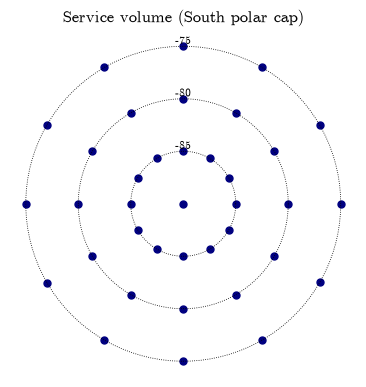

In [4]:
def south_polar_users(lat_max_deg=-75.0, dlat_deg=5.0, dlon_deg=30.0, alt_m=0.0):
    """Grid of [lat, lon, alt] (rad, rad, m) over the cap lat <= lat_max_deg."""
    lats = np.arange(-90.0, lat_max_deg + 1e-9, dlat_deg)
    lons = np.arange(0.0, 360.0, dlon_deg)
    users = [[-90.0 * RAD, 0.0, alt_m]]  # the pole itself (once)
    for la in lats:
        if la <= -89.99:
            continue
        for lo in lons:
            users.append([la * RAD, lo * RAD, alt_m])
    return np.array(users)


SERVICE_USERS = south_polar_users(lat_max_deg=-75.0, dlat_deg=5.0, dlon_deg=30.0)
MASK_DEG = 10.0  # user elevation mask
PDOP_THRESH = 6.0  # availability requirement:  PDOP < 6

print(
    f"Service volume: {len(SERVICE_USERS)} user points over the South cap (lat <= -75 deg)"
)
print(
    f"Elevation mask: {MASK_DEG:.0f} deg    |    Availability requirement: PDOP < {PDOP_THRESH:.0f}"
)

# quick look at the user grid (polar view, south)
fig, ax = plt.subplots(figsize=(4.5, 4.5))
lat_d, lon_d = SERVICE_USERS[:, 0] * DEG, SERVICE_USERS[:, 1] * DEG
r = 90 + lat_d  # 0 at pole, 15 at -75deg
ax.scatter(r * np.sin(np.deg2rad(lon_d)), r * np.cos(np.deg2rad(lon_d)), s=25, c="navy")
for ring in (5, 10, 15):
    th = np.linspace(0, 2 * np.pi, 100)
    ax.plot(ring * np.cos(th), ring * np.sin(th), "k:", lw=0.6)
    ax.text(0, ring, f"{-90+ring:.0f}", fontsize=8, ha="center", va="bottom")
ax.set_aspect("equal")
ax.set_title("Service volume (South polar cap)")
ax.axis("off")
plt.show()

## 4. Build the constellation and propagate

We fix the constellation size to **6 satellites in 3 planes** (2 satellites per plane), a minimal
symmetric Walker layout. We start from a **naive phasing** (all plane offsets = 0) &mdash; the optimizer
in Section&nbsp;7 will improve it. We propagate one **sidereal month** with two-body dynamics
(fast and, thanks to the resonance, geometrically representative of the repeating pattern).

In [5]:
N_PLANES = 3
SATS_PER_PLANE = 2

const = LunarNavConstellation.frozen_elfo(
    N_REV, ECC, N_PLANES, SATS_PER_PLANE, plane_phase=np.zeros(N_PLANES)
)
print(const.name)
print(
    f"  satellites : {const.n_sat}  ({const.n_planes} planes x {const.sats_per_plane})"
)
print(
    f"  a={const.a/1e3:.1f} km  e={const.e:.2f}  i={const.inc*DEG:.2f} deg  argp={const.argp*DEG:.0f} deg"
)

# time grid: one sidereal month at 30-min sampling
DT = 30 * pnt.SECS_MINUTE
tfs = const.epoch + np.arange(0.0, T_SIDEREAL_MONTH, DT)
print(
    f"  time grid  : {len(tfs)} steps of {DT/60:.0f} min over {T_SIDEREAL_MONTH/SECS_DAY:.2f} days"
)

pos_pa = const.propagate(tfs, model="twobody")
print(f"  positions  : {pos_pa.shape}  (n_sat, T, 3) in MOON_PA")

LunarNav-ELFO
  satellites : 6  (3 planes x 2)
  a=11265.8 km  e=0.60  i=51.76 deg  argp=90 deg
  time grid  : 1312 steps of 30 min over 27.32 days


  positions  : (6, 1312, 3)  (n_sat, T, 3) in MOON_PA


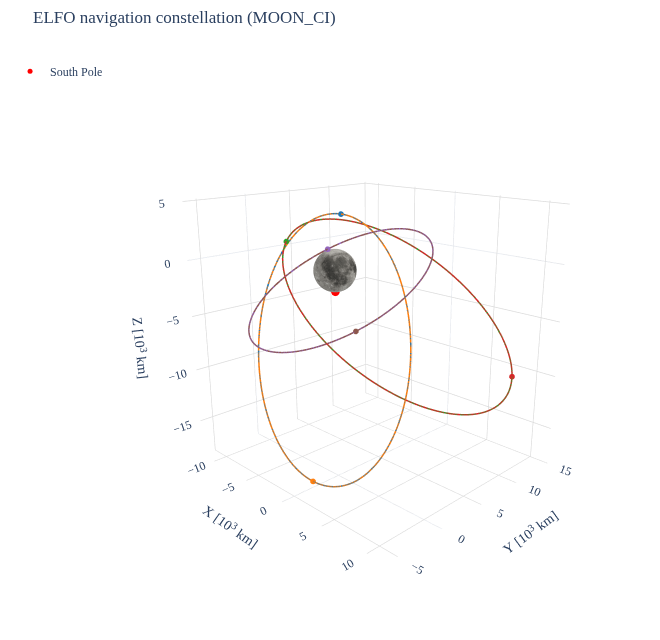

In [6]:
# --- 3D view of the constellation (Moon-inertial) ----------------------------
rv0 = const.initial_states_ci()
one_orbit = const.epoch + np.arange(0.0, const.period, 120.0)
dyn2b = pnt.CartesianTwoBodyDynamics(GM_MOON)
orbits_ci = np.array(
    [np.asarray(dyn2b.propagate(rv0[k], one_orbit))[:, :3] for k in range(const.n_sat)]
)

fig = go.Figure()
pnt.plot.plot_body(fig, pnt.MOON, size_factor=6, alpha=0.45)
pnt.plot.plot_orbits(fig, orbits_ci, t=0, marker_size=3)
fig.add_scatter3d(
    x=[0.0],
    y=[0.0],
    z=[-R_MOON / 1e6],
    mode="markers",
    marker=dict(color="red", size=5),
    name="South Pole",
)
pnt.plot.set_view(fig, azimuth=-45, elevation=18, zoom=2.7)
fig.update_layout(
    title="ELFO navigation constellation (MOON_CI)",
    width=660,
    height=660,
    margin=dict(l=10, r=10, t=45, b=10),
    legend=dict(x=0.02, y=0.98),
)
embed_plotly(fig, "ex12_constellation")

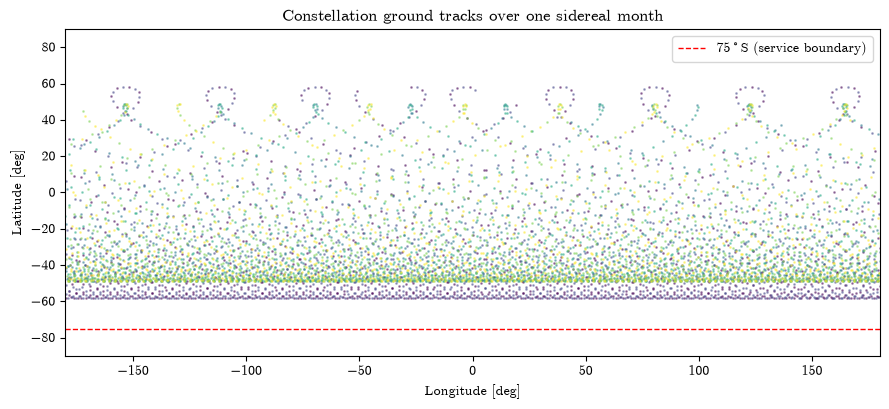

In [7]:
# --- Ground tracks over one month (Moon-fixed) -------------------------------
colors = cm.viridis(np.linspace(0, 1, const.n_sat))
# note: pnt.cart_to_lat_lon_alt returns lat/lon already in DEGREES
lla = np.array([pnt.cart_to_lat_lon_alt(pos_pa[k], R_MOON) for k in range(const.n_sat)])
fig, ax = plt.subplots(figsize=(9, 4.2))
for k in range(const.n_sat):
    lon_wrapped = ((lla[k, :, 1] + 180.0) % 360.0) - 180.0
    ax.scatter(lon_wrapped, lla[k, :, 0], s=1.0, color=colors[k], alpha=0.4)
ax.axhline(-75, color="red", ls="--", lw=1, label="75$^\\circ$S (service boundary)")
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xlabel("Longitude [deg]")
ax.set_ylabel("Latitude [deg]")
ax.set_title("Constellation ground tracks over one sidereal month")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 5. Coverage and DOP over the service volume

For every user and every epoch we count the visible satellites (elevation above the mask) and
compute the **PDOP**. Availability is the fraction of user&times;time samples with `PDOP < 6`.

In [8]:
avail0, pdop0 = const.availability(pos_pa, SERVICE_USERS, MASK_DEG, PDOP_THRESH)
nvis0 = const.n_visible(pos_pa, SERVICE_USERS, MASK_DEG)

print(f"Naive phasing (all offsets = 0):")
print(
    f"  PDOP < {PDOP_THRESH:.0f} availability : {avail0:.1f} %  (over service volume x 1 month)"
)
print(
    f"  median visible sats     : {np.median(nvis0):.0f}   (min {nvis0.min()}, max {nvis0.max()})"
)
print(f"  median PDOP (>=4 vis)    : {np.median(pdop0[pdop0 < DOP_INF]):.2f}")

Naive phasing (all offsets = 0):
  PDOP < 6 availability : 43.6 %  (over service volume x 1 month)
  median visible sats     : 5   (min 3, max 6)
  median PDOP (>=4 vis)    : 3.57


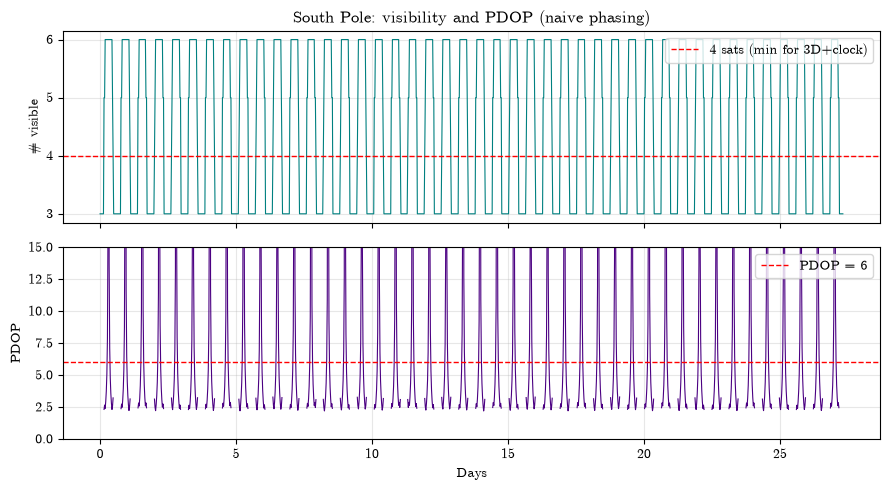

In [9]:
# --- PDOP and #visible at the South Pole vs time -----------------------------
pole = SERVICE_USERS[:1]
pdop_pole = const.compute_pdop(pos_pa, pole, MASK_DEG)[0]
nvis_pole = const.n_visible(pos_pa, pole, MASK_DEG)[0]
t_days = (tfs - tfs[0]) / SECS_DAY

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
ax1.plot(t_days, nvis_pole, lw=0.8, color="teal")
ax1.axhline(4, color="red", ls="--", lw=1, label="4 sats (min for 3D+clock)")
ax1.set_ylabel("# visible")
ax1.legend(loc="upper right")
ax1.grid(alpha=0.3)
ax1.set_title("South Pole: visibility and PDOP (naive phasing)")
pdop_plot = np.where(pdop_pole < DOP_INF, pdop_pole, np.nan)
ax2.plot(t_days, pdop_plot, lw=0.8, color="indigo")
ax2.axhline(PDOP_THRESH, color="red", ls="--", lw=1, label=f"PDOP = {PDOP_THRESH:.0f}")
ax2.set_ylim(0, 15)
ax2.set_ylabel("PDOP")
ax2.set_xlabel("Days")
ax2.legend(loc="upper right")
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

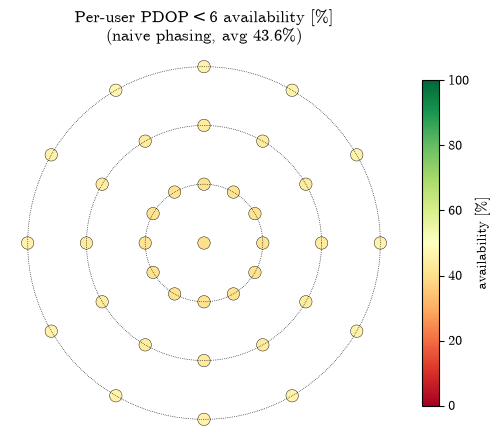

In [10]:
# --- Per-user availability map over the cap (naive phasing) ------------------
def availability_per_user(constellation, pos_pa, users, mask_deg, thr):
    pdop = constellation.compute_pdop(pos_pa, users, mask_deg)  # (n_user, T)
    return (pdop < thr).mean(axis=1) * 100.0


au0 = availability_per_user(const, pos_pa, SERVICE_USERS, MASK_DEG, PDOP_THRESH)

fig, ax = plt.subplots(figsize=(5.2, 4.6))
lat_d, lon_d = SERVICE_USERS[:, 0] * DEG, SERVICE_USERS[:, 1] * DEG
r = 90 + lat_d
sc = ax.scatter(
    r * np.sin(np.deg2rad(lon_d)),
    r * np.cos(np.deg2rad(lon_d)),
    c=au0,
    s=80,
    cmap="RdYlGn",
    vmin=0,
    vmax=100,
    edgecolors="k",
    linewidths=0.3,
)
for ring in (5, 10, 15):
    th = np.linspace(0, 2 * np.pi, 100)
    ax.plot(ring * np.cos(th), ring * np.sin(th), "k:", lw=0.5)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title(
    f"Per-user PDOP$<${PDOP_THRESH:.0f} availability [%]\n(naive phasing, avg {au0.mean():.1f}%)"
)
plt.colorbar(sc, label="availability [%]", shrink=0.8)
plt.tight_layout()
plt.show()

## 6. Required EIRP over the service volume

A navigation signal must arrive with enough carrier-to-noise density $C/N_0$ to be tracked. Using a
simple downlink budget at the LunaNet Augmented Forward Signal band ($\sim2492$&nbsp;MHz),

$$\text{EIRP}_\text{req}\,[\text{dBW}] = (C/N_0)_\text{req} + L_\text{fs} + k_B[\text{dB}] + 10\log_{10}T_\text{sys} - G_\text{rx} + L_\text{cable},$$

we compute the transmit EIRP each satellite needs to serve each visible user. The **worst case**
(maximum required EIRP) sizes the payload; it occurs at the **longest slant range** &mdash; a user seeing
a satellite near apolune on the far side of the cap.

Required EIRP over the service volume (C/N0 = 30 dB-Hz, G_rx = 6 dBi):
  min  :  -3.3 dBW  (0.46 W)
  95%  :   4.3 dBW
  max  :   4.5 dBW  (2.8 W)  <-- sizes the payload
  max slant range in view: 17140 km


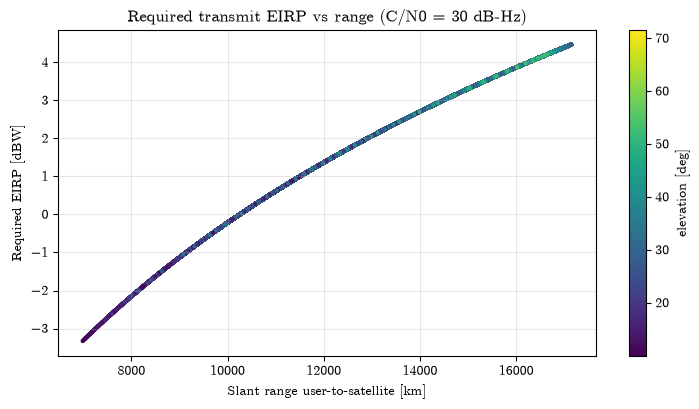

In [11]:
eirp_req, rng, elev = const.required_eirp(
    pos_pa, SERVICE_USERS, MASK_DEG, cn0_req_dbhz=30.0
)

finite = np.isfinite(eirp_req)
print(f"Required EIRP over the service volume (C/N0 = 30 dB-Hz, G_rx = 6 dBi):")
print(
    f"  min  : {np.nanmin(eirp_req):5.1f} dBW  ({10**(np.nanmin(eirp_req)/10):.2f} W)"
)
print(f"  95%  : {np.nanpercentile(eirp_req[finite], 95):5.1f} dBW")
print(
    f"  max  : {np.nanmax(eirp_req):5.1f} dBW  ({10**(np.nanmax(eirp_req)/10):.1f} W)  <-- sizes the payload"
)
print(
    f"  max slant range in view: {np.nanmax(np.where(finite, rng, np.nan))/1e3:.0f} km"
)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
sc = ax.scatter(
    rng[finite] / 1e3, eirp_req[finite], c=elev[finite] * DEG, s=4, cmap="viridis"
)
ax.set_xlabel("Slant range user-to-satellite [km]")
ax.set_ylabel("Required EIRP [dBW]")
ax.set_title("Required transmit EIRP vs range (C/N0 = 30 dB-Hz)")
ax.grid(alpha=0.3)
plt.colorbar(sc, label="elevation [deg]")
plt.tight_layout()
plt.show()

## 7. Phasing optimization

We now **optimize the satellite phasing** to maximize the `PDOP < 6` availability over the whole
service volume and the full month. By the constellation's symmetry the free variables are the
**per-plane phase offsets**; we fix plane&nbsp;0 at $0$ (a gauge choice, since a rigid shift of all
planes is just a time shift) and optimize the remaining $n_\text{planes}-1$ offsets.

**Fast objective.** Re-propagating for every candidate would be far too slow. Instead we exploit
two facts of the two-body + resonant design:

1. the CI&rarr;PA rotation $R(t)$ does not depend on phasing &rarr; **precompute it once**;
2. shifting a satellite's mean anomaly by $\Delta M$ is exactly a **time shift** $\Delta t=\Delta M/n$
   along its (inertially fixed) orbit &rarr; precompute each plane's trajectory once over an *extended*
   grid and realize any phase offset as an **index roll**.

Each objective evaluation is then just array rolls, an `einsum`, and a batched $4\times4$ inverse.

In [12]:
class PhasingEvaluator:
    """Fast availability(plane_phase) evaluator for two-body resonant ELFO constellations."""

    def __init__(self, constellation, tfs, users, mask_deg=10.0, pdop_thresh=6.0):
        self.c = constellation
        self.tfs = np.asarray(tfs)
        self.users = users
        self.mask = np.deg2rad(mask_deg)
        self.thr = pdop_thresh
        self.lent = len(tfs)
        self.dt = tfs[1] - tfs[0]
        self.n = constellation.mean_motion
        self.steps_per_orbit = int(np.ceil(constellation.period / self.dt))

        # precompute CI->PA rotations over the assessment window
        self.R = np.array(
            [
                np.array(
                    pnt.get_frame_rotation_translation(t, pnt.MOON_CI, pnt.MOON_PA)[0]
                )[:3, :3]
                for t in self.tfs
            ]
        )  # (T,3,3)

        # precompute each plane's reference (M0=0) trajectory over an EXTENDED grid
        tfs_ext = (
            constellation.epoch + np.arange(self.lent + self.steps_per_orbit) * self.dt
        )
        dyn = pnt.CartesianTwoBodyDynamics(GM_MOON)
        self.plane_ci = []
        for p in range(constellation.n_planes):
            raan = constellation.raan0 + p * 2 * np.pi / constellation.n_planes
            coe = np.array(
                [
                    constellation.a,
                    constellation.e,
                    constellation.inc,
                    raan,
                    constellation.argp,
                    0.0,
                ]
            )
            rv0 = pnt.convert_frame(
                constellation.epoch,
                pnt.classical_to_cart(coe, GM_MOON),
                pnt.MOON_OP,
                pnt.MOON_CI,
            )
            self.plane_ci.append(np.asarray(dyn.propagate(rv0, tfs_ext))[:, :3])

        # precompute user positions and ENU frames
        self.r_user = np.array([lla_to_cart(u[0], u[1], u[2]) for u in users])
        self.R_enu = np.array([enu_matrix(u[0], u[1]) for u in users])

    def positions_pa(self, plane_phase):
        """Assemble (n_sat, T, 3) MOON_PA positions for the given per-plane phase offsets."""
        out = np.empty((self.c.n_sat, self.lent, 3))
        k = 0
        for p in range(self.c.n_planes):
            for s in range(self.c.sats_per_plane):
                phase = (s * 2 * np.pi / self.c.sats_per_plane + plane_phase[p]) % (
                    2 * np.pi
                )
                roll = int(round((phase / self.n) / self.dt)) % self.steps_per_orbit
                ci = self.plane_ci[p][roll : roll + self.lent]
                out[k] = np.einsum("kij,kj->ki", self.R, ci)
                k += 1
        return out

    def availability(self, plane_phase):
        pos = self.positions_pa(plane_phase)
        los = pos[None] - self.r_user[:, None, None, :]
        enu = np.einsum("uij,uslj->usli", self.R_enu, los)
        rng = np.linalg.norm(enu, axis=-1)
        elev = np.arcsin(np.clip(enu[..., 2] / rng, -1, 1))
        vis = elev >= self.mask
        u = np.moveaxis(enu / rng[..., None], 1, -2)  # (nu, T, ns, 3)
        v = np.moveaxis(vis, 1, -1)  # (nu, T, ns)
        pdop = batched_pdop(u, v)
        return float((pdop < self.thr).mean() * 100.0)


evaluator = PhasingEvaluator(const, tfs, SERVICE_USERS, MASK_DEG, PDOP_THRESH)

# sanity: fast evaluator must match the class computation for the naive phasing
fast0 = evaluator.availability(np.zeros(N_PLANES))
print(f"availability check  ->  class: {avail0:.1f}%   fast: {fast0:.1f}%")

availability check  ->  class: 43.6%   fast: 43.6%


Grid optimum: plane offsets = [  0.  30. 150.] deg  ->  availability 69.2%
Landscape spans 20.2% (worst) to 69.2% (best) -- phasing matters a lot!


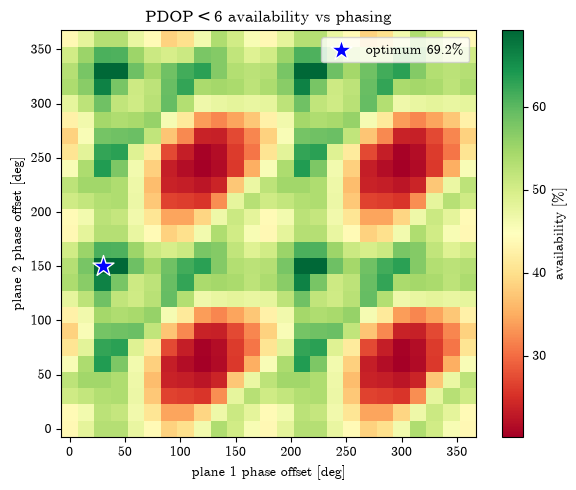

In [13]:
# --- Optimization landscape: sweep the two free per-plane offsets ------------
grid = np.linspace(0, 2 * np.pi, 25)  # ~15-deg resolution
land = np.zeros((grid.size, grid.size))
for i, p1 in enumerate(grid):
    for j, p2 in enumerate(grid):
        land[i, j] = evaluator.availability([0.0, p1, p2])

imax = np.unravel_index(np.argmax(land), land.shape)
best_grid = np.array([0.0, grid[imax[0]], grid[imax[1]]])
print(
    f"Grid optimum: plane offsets = {best_grid*DEG} deg  ->  availability {land.max():.1f}%"
)
print(
    f"Landscape spans {land.min():.1f}% (worst) to {land.max():.1f}% (best) -- phasing matters a lot!"
)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.pcolormesh(grid * DEG, grid * DEG, land.T, cmap="RdYlGn", shading="auto")
ax.scatter(
    best_grid[1] * DEG,
    best_grid[2] * DEG,
    marker="*",
    s=250,
    color="blue",
    edgecolors="white",
    label=f"optimum {land.max():.1f}%",
)
ax.set_xlabel("plane 1 phase offset [deg]")
ax.set_ylabel("plane 2 phase offset [deg]")
ax.set_title(f"PDOP$<${PDOP_THRESH:.0f} availability vs phasing")
ax.legend(loc="upper right")
plt.colorbar(im, label="availability [%]")
plt.tight_layout()
plt.show()

In [14]:
# --- Refine with a global optimizer (differential evolution) -----------------
def neg_availability(x):
    return -evaluator.availability(np.concatenate([[0.0], x]))


result = differential_evolution(
    neg_availability,
    bounds=[(0, 2 * np.pi)] * (N_PLANES - 1),
    maxiter=20,
    popsize=12,
    tol=1e-4,
    seed=0,
    polish=False,
)
best_phase = np.concatenate([[0.0], result.x])
avail_opt = -result.fun
print(f"Optimized plane offsets : {best_phase*DEG} deg")
print(f"Optimized availability  : {avail_opt:.1f} %   (naive was {avail0:.1f} %)")

Optimized plane offsets : [  0.     209.2636 328.0124] deg
Optimized availability  : 72.0 %   (naive was 43.6 %)


## 8. Optimized design &mdash; results and high-fidelity verification

We apply the optimized phasing, recompute the coverage metrics, and compare with the naive design.
Finally we **verify** the optimized constellation with full **N-body dynamics** (Moon 7&times;1 gravity +
Earth + Sun third bodies) over the month &mdash; to see how the two-body&ndash;optimized availability fares
under realistic perturbations (it drops somewhat, as the slow frozen libration reshapes the geometry
away from the idealized two-body optimum, but stays well above the naive baseline) and to confirm the
orbits remain **frozen** (bounded $e$&ndash;$\omega$ libration). A production design would optimize the
phasing directly on the N-body trajectories using the same objective.

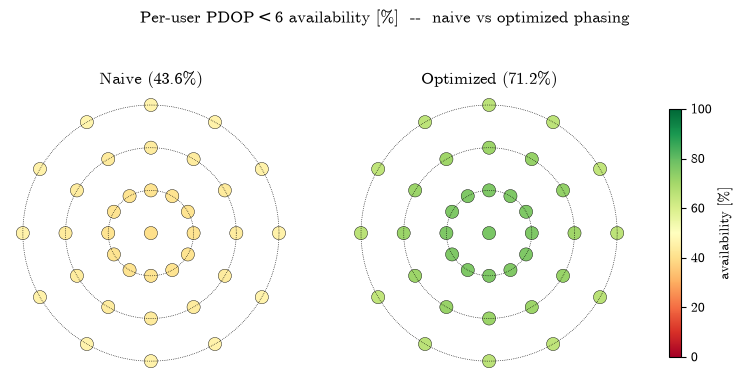

In [15]:
const.set_phasing(best_phase)
pos_opt = const.propagate(tfs, model="twobody")
avail_opt2, pdop_opt = const.availability(pos_opt, SERVICE_USERS, MASK_DEG, PDOP_THRESH)
au_opt = availability_per_user(const, pos_opt, SERVICE_USERS, MASK_DEG, PDOP_THRESH)

# side-by-side per-user availability maps: naive vs optimized
fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))
for ax, au, title in [
    (axes[0], au0, f"Naive ({au0.mean():.1f}%)"),
    (axes[1], au_opt, f"Optimized ({au_opt.mean():.1f}%)"),
]:
    r = 90 + SERVICE_USERS[:, 0] * DEG
    lon_d = SERVICE_USERS[:, 1] * DEG
    sc = ax.scatter(
        r * np.sin(np.deg2rad(lon_d)),
        r * np.cos(np.deg2rad(lon_d)),
        c=au,
        s=90,
        cmap="RdYlGn",
        vmin=0,
        vmax=100,
        edgecolors="k",
        linewidths=0.3,
    )
    for ring in (5, 10, 15):
        th = np.linspace(0, 2 * np.pi, 100)
        ax.plot(ring * np.cos(th), ring * np.sin(th), "k:", lw=0.5)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)
fig.suptitle(
    f"Per-user PDOP$<${PDOP_THRESH:.0f} availability [%]  --  naive vs optimized phasing"
)
plt.colorbar(sc, ax=axes, label="availability [%]", shrink=0.7)
plt.show()

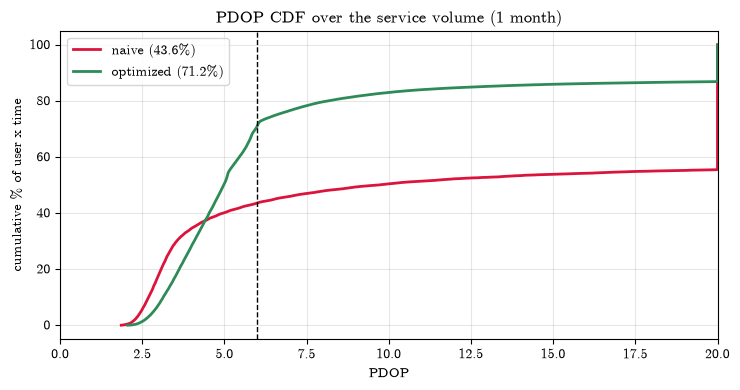

In [16]:
# --- PDOP distribution: naive vs optimized -----------------------------------
fig, ax = plt.subplots(figsize=(7.5, 4))
for pd, lab, col in [
    (pdop0, f"naive ({avail0:.1f}%)", "crimson"),
    (pdop_opt, f"optimized ({avail_opt2:.1f}%)", "seagreen"),
]:
    vals = np.sort(pd.ravel())
    cdf = np.arange(1, vals.size + 1) / vals.size * 100
    ax.plot(np.clip(vals, 0, 20), cdf, lw=2, label=lab, color=col)
ax.axvline(PDOP_THRESH, color="k", ls="--", lw=1)
ax.set_xlabel("PDOP")
ax.set_ylabel("cumulative % of user x time")
ax.set_title("PDOP CDF over the service volume (1 month)")
ax.set_xlim(0, 20)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# --- High-fidelity verification: full N-body over one month ------------------
print(
    "Propagating optimized constellation with full N-body dynamics (this takes ~1 min)..."
)
pos_nbody = const.propagate(tfs, model="nbody", moon_deg_ord=(7, 1))
avail_nb, pdop_nb = const.availability(pos_nbody, SERVICE_USERS, MASK_DEG, PDOP_THRESH)
print(f"Availability  ->  two-body: {avail_opt2:.1f} %    N-body: {avail_nb:.1f} %")

Propagating optimized constellation with full N-body dynamics (this takes ~1 min)...


Availability  ->  two-body: 71.2 %    N-body: 60.3 %


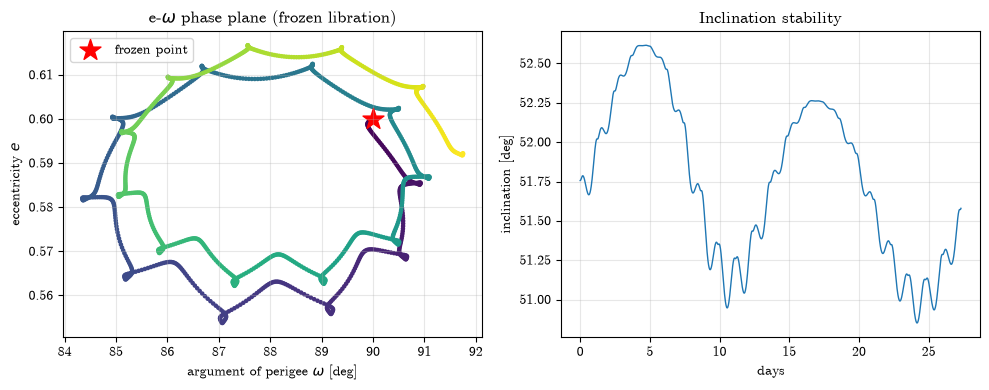

In [18]:
# --- Confirm the orbits stay frozen: e-omega libration (N-body, in MOON_OP) --
sat0 = const.initial_states_ci()[0]
dynN = const._make_dynamics("nbody", (7, 1))
rv_ci = np.asarray(dynN.propagate(sat0, tfs))
rv_op = pnt.convert_frame(tfs, rv_ci, pnt.MOON_CI, pnt.MOON_OP)
coe_op = np.array([pnt.cart_to_classical(rv_op[k], GM_MOON) for k in range(len(tfs))])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.scatter(coe_op[:, 4] * DEG, coe_op[:, 1], c=t_days, cmap="viridis", s=5)
ax1.scatter([90], [ECC], marker="*", s=250, color="red", label="frozen point")
ax1.set_xlabel("argument of perigee $\\omega$ [deg]")
ax1.set_ylabel("eccentricity $e$")
ax1.set_title("e-$\\omega$ phase plane (frozen libration)")
ax1.legend()
ax1.grid(alpha=0.3)
ax2.plot(t_days, coe_op[:, 2] * DEG, lw=1)
ax2.set_xlabel("days")
ax2.set_ylabel("inclination [deg]")
ax2.set_title("Inclination stability")
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Summary

This notebook used LuPNT as a constellation-design sandbox:

- an ELFO family was selected from resonance and frozen-orbit conditions;
- a six-satellite, three-plane Walker-style constellation was generated;
- south-pole user coverage, PDOP availability, and required EIRP were evaluated over a sidereal month;
- per-plane phasing was optimized with a fast time-shift objective;
- the optimized design was checked again with higher-fidelity N-body propagation.

The same framework can be extended by adding more satellites, changing the service volume, using weighted DOP from link-budget-derived measurement noise, or adding station-keeping cost as a second objective.